<a href="https://colab.research.google.com/github/sanmquin/AI/blob/main/src/Graphiko/Fetch-Business-Cluster-Videos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fetch videos for business-cluster channels
This notebook reuses the Graphiko business-cluster lookup logic and then fetches Finder videos grouped by channel.


## Environment setup and data connections
This cell installs runtime dependencies and validates connectivity to MongoDB. The output confirms whether the notebook can read Finder collections before any analysis begins.


In [1]:
# Install runtime dependencies
!pip install -q pymongo dnspython pinecone pandas numpy matplotlib seaborn scikit-learn

import pymongo
from pymongo import MongoClient
from google.colab import userdata

try:
    # Retrieve the URI from Colab Secrets
    uri = userdata.get('MONGODB_URI')
    client = MongoClient(uri)

    # Send a ping to confirm connection
    client.admin.command('ping')
    print('✅ Successfully connected to MongoDB!')
except Exception as e:
    print(f'❌ MongoDB connection failed: {e}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 742.8/742.8 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.7/280.7 kB 13.7 MB/s eta 0:00:00
✅ Successfully connected to MongoDB!


## Resolve the latest business cluster context
This cell opens Finder collections, detects the latest clustering version, and selects the business cluster anchor that defines the analysis universe.


In [2]:
# Access Finder DB collections and identify the latest business cluster
db = client['finder']
clusters_col = db['ChannelDescriptions_clusters']
items_col = db['ChannelDescriptions_items']
channels_col = db['channels']
videos_col = db['videos']

latest = clusters_col.find_one(sort=[('version', -1), ('createdAt', -1)])
latest_version = latest['version'] if latest else None
print('Latest cluster version:', latest_version)

if latest_version is None:
    print('No clusters found.')
    business_cluster = None
else:
    business_cluster = clusters_col.find_one({
        'version': latest_version,
        'name': {'$regex': '^business', '$options': 'i'}
    })

if business_cluster:
    business_cluster_id = business_cluster['_id']
    print('Business cluster found:', business_cluster.get('name'))
    print('Business cluster _id:', business_cluster_id)
else:
    business_cluster_id = None
    print('No business cluster found in the latest version.')


Latest cluster version: 2
Business cluster found: Business, Venture Capital, and Entrepreneurship
Business cluster _id: 69e41878685f30ed081ec5a6


## Expand the business cluster to channel metadata
This cell maps cluster items to channel records, producing channel IDs, channel titles, and descriptions used later for embeddings and reporting.


In [3]:
# Resolve channels associated with the business cluster
if business_cluster_id is None:
    print('Cannot fetch channels without a business cluster id.')
    channel_ids = []
    business_channels = []
else:
    item_docs = list(items_col.find(
        {'clusterId': business_cluster_id},
        {'_id': 0, 'textId': 1}
    ))
    channel_ids = [d['textId'] for d in item_docs]

    business_channels = list(channels_col.find(
        {'channelId': {'$in': channel_ids}},
        {'_id': 0, 'channelId': 1, 'title': 1, 'description': 1}
    ))

    print(f'Business cluster has {len(channel_ids)} channel ids and {len(business_channels)} channel docs.')
    for ch in sorted(business_channels, key=lambda x: x.get('title', ''))[:20]:
        print(f"- {ch.get('title', '(untitled)')} ({ch.get('channelId')})")

    if len(business_channels) > 20:
        print(f'... and {len(business_channels) - 20} more channels')


Business cluster has 27 channel ids and 27 channel docs.
- 20VC with Harry Stebbings (UCf0PBRjhf0rF8fWBIxTuoWA)
- ARK Invest (UCK-zlnUfoDHzUwXcbddtnkg)
- Alex Hormozi (UCUyDOdBWhC1MCxEjC46d-zw)
- All-In Podcast (UCESLZhusAkFfsNsApnjF_Cg)
- Anthony Pompliano (UCevXpeL8cNyAnww-NqJ4m2w)
- Asianometry (UC1LpsuAUaKoMzzJSEt5WImw)
- Bg2 Pod (UC-yRDvpR99LUc5l7i7jLzew)
- Bloomberg Originals (UCUMZ7gohGI9HcU9VNsr2FJQ)
- Dan Martell (UCA-mWX9CvCTVFWRMb9bKc9w)
- Garry Tan (UCIBgYfDjtWlbJhg--Z4sOgQ)
- Greg Isenberg (UCPjNBjflYl0-HQtUvOx0Ibw)
- Joe Lonsdale (UCJEDniyP_YtcsXikBELqicw)
- Lenny's Podcast (UC6t1O76G0jYXOAoYCm153dA)
- My First Million (UCyaN6mg5u8Cjy2ZI4ikWaug)
- Network State Podcast (UCKrpnfpTwncQ050VFXcVkuQ)
- Patrick Boyle (UCASM0cgfkJxQ1ICmRilfHLw)
- Peter H. Diamandis (UCvxm0qTrGN_1LMYgUaftWyQ)
- Principles by Ray Dalio (UCqvaXJ1K3HheTPNjH-KpwXQ)
- Real Vision Presents (UCBH5VZE_Y4F3CMcPIzPEB5A)
- Sequoia Capital (UCWrF0oN6unbXrWsTN7RctTw)
... and 7 more channels


## Fetch videos for each business-cluster channel
Retrieves videos from Finder's `videos` collection for all channels in the business cluster and groups them by `channelId`.


This cell fetches all videos for the business-cluster channels and groups them by `channelId`. It also prints quick per-channel diagnostics to verify data coverage.


In [18]:
from collections import defaultdict

if not channel_ids:
    print('No channel ids available to query videos.')
    videos_by_channel = {}
else:
    cursor = videos_col.find(
        {'channelId': {'$in': channel_ids}},
        {
            '_id': 0,
            'videoId': 1,
            'channelId': 1,
            'title': 1,
            'publishedAt': 1,
            'viewCount': 1
        }
    ).sort([('channelId', 1), ('publishedAt', -1)])

    videos_by_channel = defaultdict(list)
    for doc in cursor:
        videos_by_channel[doc['channelId']].append(doc)

    print(f'Fetched videos for {len(videos_by_channel)} channels.')
    total_videos = sum(len(v) for v in videos_by_channel.values())
    print(f'Total videos fetched: {total_videos}')

    for channel in business_channels:
        cid = channel.get('channelId')
        title = channel.get('title', '(untitled)')
        channel_videos = videos_by_channel.get(cid, [])
        print(f'{title} ({cid}) -> {len(channel_videos)} videos')

        # Show up to 3 most recent videos for quick inspection
        for video in channel_videos[:1]:
            print(
                f"  • {video.get('title', '(no title)')} "
                f"| views={video.get('viewCount')} | published={video.get('publishedAt')}"
            )


Fetched videos for 27 channels.
Total videos fetched: 1344
Bg2 Pod (UC-yRDvpR99LUc5l7i7jLzew) -> 44 videos
  • ChatGPT – The Super Assistant Era | BG2 Guest Interview | views=7574 | published=2026-03-15 16:25:13
The Prof G Pod – Scott Galloway (UC1E1SVcVyU3ntWMSQEp38Yw) -> 50 videos
  • The Hidden Engine of China’s AI Boom | China Decode | views=17697 | published=2026-04-21 08:00:53
Asianometry (UC1LpsuAUaKoMzzJSEt5WImw) -> 50 videos
  • How To Test 208 Billion Transistors | views=149040 | published=2026-04-12 23:00:26
Lenny's Podcast (UC6t1O76G0jYXOAoYCm153dA) -> 50 videos
  • Head of Growth (Anthropic):  “Claude is growing itself at this point” | views=77764 | published=2026-04-05 12:30:57
a16z (UC9cn0TuPq4dnbTY-CBsm8XA) -> 50 videos
  • The Era of AI Agents | Aaron Levie on The a16z Show | views=19976 | published=2026-04-08 14:30:00
Dan Martell (UCA-mWX9CvCTVFWRMb9bKc9w) -> 50 videos
  • How to Make Time For Everything (Seriously, everything) | views=63671 | published=2026-04-20 13:

## Build a tabular video snapshot
This cell flattens grouped videos into a DataFrame so subsequent joins, metrics, and artifact exports can use a consistent tabular schema.


In [5]:
# Optional: flatten all fetched videos to a DataFrame for downstream analysis/export
import pandas as pd

all_videos = [v for vids in videos_by_channel.values() for v in vids] if videos_by_channel else []
videos_df = pd.DataFrame(all_videos)
print('videos_df shape:', videos_df.shape)
videos_df.head(10)


videos_df shape: (1344, 5)


,videoId,channelId,publishedAt,title,viewCount
0,MIKej1HCRW0,UC-yRDvpR99LUc5l7i7jLzew,2026-03-15 16:25:13,ChatGPT – The Super Assistant Era | BG2 Guest ...,7574
1,jA8ZQfq_Hzs,UC-yRDvpR99LUc5l7i7jLzew,2025-12-23 23:15:04,AI Enterprise - Databricks & Glean | BG2 Guest...,24210
2,Gnl833wXRz0,UC-yRDvpR99LUc5l7i7jLzew,2025-10-31 23:17:31,All things AI w @altcap @sama & @satyanadella....,228167
3,KX6q6lvoYtM,UC-yRDvpR99LUc5l7i7jLzew,2025-10-14 23:56:17,"AI Bubble, Stablecoin Boom, and Runnin' Down a...",71463
4,pE6sw_E9Gh0,UC-yRDvpR99LUc5l7i7jLzew,2025-09-26 03:36:04,"NVIDIA: OpenAI, Future of Compute, and the Ame...",426866
5,yLTSqBzKG2s,UC-yRDvpR99LUc5l7i7jLzew,2025-09-11 21:25:36,Inside OpenAI Enterprise: Forward Deployed Eng...,23451
6,hUJz55AsUz4,UC-yRDvpR99LUc5l7i7jLzew,2025-08-28 23:51:07,"China, China, China. Breaking Down China’s Tec...",114510
7,fTqINzeudJ4,UC-yRDvpR99LUc5l7i7jLzew,2025-07-31 15:25:00,"China Open-Source, Compute Arms Race, Reorderi...",54888
8,X52BNWZrXSk,UC-yRDvpR99LUc5l7i7jLzew,2025-07-10 23:23:42,"Michael Dell – Invest America Act Becomes Law,...",75922
9,IOoRXSyezBE,UC-yRDvpR99LUc5l7i7jLzew,2025-06-21 16:36:30,Coatue Pt2. Open AI’s Kevin Weil Dives into Al...,42867


## Pinecone embedding workflow (reused fetch-or-embed pattern)
This section reuses the same **fetch then embed-if-missing** design used in `Embeddings-Graph.ipynb` (`get_or_create_channel_description_embeddings`) and generalizes it into a helper for both:
- channel descriptions (`ChannelDescriptions` namespace)
- video titles (`VideoTitles` namespace)

That gives idempotent runs: existing vectors are fetched, and only missing records are embedded/upserted.


This cell authenticates against Pinecone and opens the `finder` index. The resulting client and index objects are reused by the embedding fetch-or-create workflow.


In [6]:
from pinecone import Pinecone

try:
    pinecone_api_key = userdata.get('PINECONE_API_KEY')
    pc = Pinecone(api_key=pinecone_api_key)
    pinecone_index = pc.Index('finder')
    print('✅ Connected to Pinecone index: finder')
except Exception as e:
    print(f'❌ Pinecone connection failed: {e}')


✅ Connected to Pinecone index: finder


## Define reusable embedding fetch-or-create helper
This helper first fetches existing vectors, embeds only missing texts, upserts them, and returns a complete in-memory embedding dictionary for downstream analysis.


In [7]:
import numpy as np

def fetch_or_embed_texts(
    pc_client,
    index,
    namespace,
    id_to_text,
    model="multilingual-e5-large",
    batch_size=96
):
    """
    1) Fetch existing vectors by id from Pinecone.
    2) Embed missing texts.
    3) Upsert missing vectors.
    4) Return dict[str, list[float]].
    """

    # Normalize keys once, so ids and text lookups stay consistent
    normalized = {
        str(k): v for k, v in id_to_text.items()
        if v is not None and str(v).strip() != ""
    }

    ids = list(normalized.keys())
    embeddings = {}

    # Fetch existing vectors
    for i in range(0, len(ids), batch_size):
        batch_ids = ids[i:i + batch_size]
        response = index.fetch(ids=batch_ids, namespace=namespace)
        vectors = getattr(response, "vectors", {}) or {}

        for rid, payload in vectors.items():
            values = payload.get("values") if isinstance(payload, dict) else getattr(payload, "values", None)
            if values is not None:
                embeddings[rid] = values

    # Embed missing vectors
    missing_ids = [rid for rid in ids if rid not in embeddings]

    for i in range(0, len(missing_ids), batch_size):
        batch_missing = missing_ids[i:i + batch_size]
        input_texts = [normalized[rid] for rid in batch_missing]

        embed_resp = pc_client.inference.embed(
            model=model,
            inputs=input_texts,
            parameters={"input_type": "passage"}
        )

        rows = getattr(embed_resp, "data", embed_resp)

        to_upsert = []
        for rid, row in zip(batch_missing, rows):
            # Pinecone returns "values", not "embedding"
            values = row.get("values") if isinstance(row, dict) else getattr(row, "values", None)
            if values is None:
                raise ValueError(f"No embedding values returned for id={rid}")

            embeddings[rid] = values
            to_upsert.append({
                "id": rid,
                "values": values,
                "metadata": {"text": normalized[rid][:1000]}
            })

        if to_upsert:
            index.upsert(vectors=to_upsert, namespace=namespace)

    return embeddings


## Prepare channel-description and video-title embedding workloads
This cell builds clean text dictionaries for channel descriptions and video titles, filtering out empty records before embedding retrieval.


In [8]:
# Build text dictionaries for embedding workloads
channel_desc_text = {
    str(ch.get('channelId')): (ch.get('description') or '').strip()
    for ch in business_channels
    if ch.get('channelId') and (ch.get('description') or '').strip()
}

video_title_text = {}
for cid, vids in videos_by_channel.items():
    for v in vids:
        vid = str(v.get('videoId')) if v.get('videoId') else None
        title = (v.get('title') or '').strip()
        if vid and title:
            video_title_text[vid] = title

print(f'Channels with descriptions: {len(channel_desc_text)}')
print(f'Videos with titles: {len(video_title_text)}')


Channels with descriptions: 27
Videos with titles: 1344


## Materialize embeddings for channels and videos
This cell executes the fetch-or-embed flow for both namespaces and reports final embedding coverage used in the distance analysis.


In [9]:
channel_desc_embeddings = fetch_or_embed_texts(
    pc_client=pc,
    index=pinecone_index,
    namespace='ChannelDescriptions',
    id_to_text=channel_desc_text,
)

video_title_embeddings = fetch_or_embed_texts(
    pc_client=pc,
    index=pinecone_index,
    namespace='VideoTitles',
    id_to_text=video_title_text,
)

print(f'Channel-description embeddings available: {len(channel_desc_embeddings)}')
print(f'Video-title embeddings available: {len(video_title_embeddings)}')


Channel-description embeddings available: 27
Video-title embeddings available: 1344


## Build cross-channel semantic displacement profiles
Instead of one distance per video, this section computes each video's cosine distance to **every** business-cluster channel description. That yields a 27-dimensional (or N-channel) displacement vector per video and preserves directional movement information.


In [10]:
import numpy as np
import pandas as pd


def cosine_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return np.nan
    return 1.0 - float(np.dot(a, b) / denom)


channel_desc_lookup = {str(ch.get('channelId')): ch for ch in business_channels if ch.get('channelId')}
anchor_channel_ids = sorted(channel_desc_embeddings.keys())

records = []
for cid, vids in videos_by_channel.items():
    home_cid = str(cid)
    if home_cid not in anchor_channel_ids:
        continue

    for v in vids:
        vid = str(v.get('videoId')) if v.get('videoId') else None
        v_vec = video_title_embeddings.get(vid)
        if v_vec is None:
            continue

        distance_vector = {
            anchor_cid: cosine_distance(v_vec, channel_desc_embeddings[anchor_cid])
            for anchor_cid in anchor_channel_ids
        }

        home_distance = distance_vector.get(home_cid, np.nan)

        row = {
            'home_channel_id': home_cid,
            'home_channel_title': channel_desc_lookup.get(home_cid, {}).get('title'),
            'video_id': vid,
            'video_title': v.get('title'),
            'view_count': pd.to_numeric(v.get('viewCount'), errors='coerce'),
            'published_at': v.get('publishedAt'),
            'distance_to_home': home_distance,
            'closeness_to_home': 1.0 - home_distance if pd.notna(home_distance) else np.nan,
        }
        for anchor_cid, dist in distance_vector.items():
            row[f'distance_to_{anchor_cid}'] = dist
        records.append(row)

cross_distance_df = pd.DataFrame(records)
print('Cross-channel distance dataset shape:', cross_distance_df.shape)
print('Anchor channels:', len(anchor_channel_ids))
cross_distance_df.head(5)


Cross-channel distance dataset shape: (1344, 35)
Anchor channels: 27


,home_channel_id,home_channel_title,video_id,video_title,view_count,published_at,distance_to_home,closeness_to_home,distance_to_UC-yRDvpR99LUc5l7i7jLzew,distance_to_UC1E1SVcVyU3ntWMSQEp38Yw,...,distance_to_UCUyDOdBWhC1MCxEjC46d-zw,distance_to_UCWrF0oN6unbXrWsTN7RctTw,distance_to_UCcefcZRL2oaA_uBNeo5UOWg,distance_to_UCevXpeL8cNyAnww-NqJ4m2w,distance_to_UCf0PBRjhf0rF8fWBIxTuoWA,distance_to_UCkkhmBWfS7pILYIk0izkc3A,distance_to_UCqvaXJ1K3HheTPNjH-KpwXQ,distance_to_UCvxm0qTrGN_1LMYgUaftWyQ,distance_to_UCyaN6mg5u8Cjy2ZI4ikWaug,distance_to_UCznv7Vf9nBdJYvBagFdAHWw
0,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,MIKej1HCRW0,ChatGPT – The Super Assistant Era | BG2 Guest ...,7574,2026-03-15 16:25:13,0.171154,0.828846,0.171154,0.249593,...,0.159616,0.224474,0.243720,0.238584,0.198860,0.177884,0.244237,0.226153,0.207818,0.218850
1,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,jA8ZQfq_Hzs,AI Enterprise - Databricks & Glean | BG2 Guest...,24210,2025-12-23 23:15:04,0.168371,0.831629,0.168371,0.245938,...,0.152881,0.202651,0.238831,0.230017,0.193472,0.182331,0.226460,0.236725,0.205034,0.224378
2,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,Gnl833wXRz0,All things AI w @altcap @sama & @satyanadella....,228167,2025-10-31 23:17:31,0.121647,0.878353,0.121647,0.216898,...,0.175018,0.223561,0.234215,0.219356,0.200425,0.166961,0.245872,0.223108,0.182118,0.226688
3,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,KX6q6lvoYtM,"AI Bubble, Stablecoin Boom, and Runnin' Down a...",71463,2025-10-14 23:56:17,0.126358,0.873642,0.126358,0.208998,...,0.170632,0.190897,0.220467,0.201339,0.193060,0.174045,0.221728,0.212394,0.171324,0.217271
4,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,pE6sw_E9Gh0,"NVIDIA: OpenAI, Future of Compute, and the Ame...",426866,2025-09-26 03:36:04,0.128379,0.871621,0.128379,0.213779,...,0.172868,0.195960,0.226074,0.218811,0.204314,0.182462,0.227219,0.209830,0.187137,0.215030


## Load subscription graph and construct directional affinity field
This cell loads the subscriptions normalized-distance adjacency matrix and transforms each home-channel outgoing row into an affinity profile where **higher means audience-nearer**. The transform inverts distance (`max - d`) and normalizes weights to sum to 1.


In [11]:
from google.colab import drive
from pathlib import Path


drive.mount('/content/drive')

sub_matrix_path = Path('/content/drive/MyDrive/Graphiko/graphs/subscriptions_normalized_distance/latest/adjacency_matrix.csv')
sub_df = pd.read_csv(sub_matrix_path, index_col=0)
sub_df.index = sub_df.index.map(str)
sub_df.columns = sub_df.columns.map(str)

common_channels = [cid for cid in anchor_channel_ids if cid in sub_df.index and cid in sub_df.columns]
sub_df = sub_df.loc[common_channels, common_channels]

# Convert row-normalized distances to affinity where larger = closer audience adjacency
sub_affinity = sub_df.apply(lambda row: row.max() - row, axis=1)
sub_affinity = sub_affinity.div(sub_affinity.sum(axis=1).replace(0, np.nan), axis=0)

print('Subscription matrix shape (aligned):', sub_df.shape)
print('Affinity matrix shape:', sub_affinity.shape)
sub_affinity.head(3)


Mounted at /content/drive
Subscription matrix shape (aligned): (27, 27)
Affinity matrix shape: (27, 27)


,UC-yRDvpR99LUc5l7i7jLzew,UC1E1SVcVyU3ntWMSQEp38Yw,UC1LpsuAUaKoMzzJSEt5WImw,UC6t1O76G0jYXOAoYCm153dA,UC9cn0TuPq4dnbTY-CBsm8XA,UCA-mWX9CvCTVFWRMb9bKc9w,UCASM0cgfkJxQ1ICmRilfHLw,UCBH5VZE_Y4F3CMcPIzPEB5A,UCESLZhusAkFfsNsApnjF_Cg,UCIBgYfDjtWlbJhg--Z4sOgQ,...,UCUyDOdBWhC1MCxEjC46d-zw,UCWrF0oN6unbXrWsTN7RctTw,UCcefcZRL2oaA_uBNeo5UOWg,UCevXpeL8cNyAnww-NqJ4m2w,UCf0PBRjhf0rF8fWBIxTuoWA,UCkkhmBWfS7pILYIk0izkc3A,UCqvaXJ1K3HheTPNjH-KpwXQ,UCvxm0qTrGN_1LMYgUaftWyQ,UCyaN6mg5u8Cjy2ZI4ikWaug,UCznv7Vf9nBdJYvBagFdAHWw
row_node_id,,,,,,,,,,,,,,,,,,,,,
UC-yRDvpR99LUc5l7i7jLzew,0.072526,0.029011,0.018132,0.029011,0.058021,0.000000,0.029011,0.018132,0.056985,0.029011,...,0.029011,0.036263,0.054395,0.029011,0.045329,0.045329,0.036263,0.048351,0.041444,0.050768
UC1E1SVcVyU3ntWMSQEp38Yw,0.042458,0.053073,0.026536,0.045491,0.047765,0.000000,0.042458,0.039805,0.047176,0.035382,...,0.039805,0.039805,0.047176,0.026536,0.035382,0.042458,0.042458,0.045491,0.035382,0.044227
UC1LpsuAUaKoMzzJSEt5WImw,0.037355,0.000000,0.074710,0.024903,0.062258,0.037355,0.063216,0.049806,0.063216,0.037355,...,0.000000,0.024903,0.053364,0.024903,0.024903,0.037355,0.037355,0.044826,0.024903,0.044826


## Score each video against the subscription gradient
For each video, this cell compares semantic movement (`distance_to_home - distance_to_anchor`) against the home channel's affinity field. Positive gradient score means the video moves toward audience-near channels; negative means it moves against likely audience adjacency.


In [12]:
def safe_corr(x, y, method='pearson'):
    tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(tmp) < 3:
        return np.nan
    return tmp['x'].corr(tmp['y'], method=method)


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights)
    if mask.sum() == 0 or weights[mask].sum() == 0:
        return np.nan
    return float(np.average(values[mask], weights=weights[mask]))


movement_cols = [f'distance_to_{cid}' for cid in common_channels]

scored_rows = []
for _, row in cross_distance_df.iterrows():
    h = str(row['home_channel_id'])
    if h not in sub_affinity.index:
        continue

    distances = pd.Series({cid: row.get(f'distance_to_{cid}', np.nan) for cid in common_channels}, dtype='float64')
    if distances.isna().all():
        continue

    home_distance = row.get('distance_to_home', np.nan)
    movement = home_distance - distances  # positive => closer to anchor than to home
    affinities = sub_affinity.loc[h]

    valid = movement.notna() & affinities.notna()
    if valid.sum() < 3:
        continue

    gradient_alignment = safe_corr(movement[valid], affinities[valid], method='spearman')
    weighted_gradient_score = weighted_mean(movement[valid], affinities[valid])

    out = row.to_dict()
    out['gradient_alignment_spearman'] = gradient_alignment
    out['gradient_weighted_score'] = weighted_gradient_score
    scored_rows.append(out)

scored_df = pd.DataFrame(scored_rows)
print('Scored videos:', scored_df.shape)
scored_df[['home_channel_title', 'video_title', 'closeness_to_home', 'gradient_alignment_spearman', 'gradient_weighted_score']].head(10)


Scored videos: (1344, 37)


,home_channel_title,video_title,closeness_to_home,gradient_alignment_spearman,gradient_weighted_score
0,Bg2 Pod,ChatGPT – The Super Assistant Era | BG2 Guest ...,0.828846,0.118693,-0.036007
1,Bg2 Pod,AI Enterprise - Databricks & Glean | BG2 Guest...,0.831629,0.018855,-0.034746
2,Bg2 Pod,All things AI w @altcap @sama & @satyanadella....,0.878353,0.134147,-0.073635
3,Bg2 Pod,"AI Bubble, Stablecoin Boom, and Runnin' Down a...",0.873642,0.073565,-0.064182
4,Bg2 Pod,"NVIDIA: OpenAI, Future of Compute, and the Ame...",0.871621,0.050073,-0.064497
5,Bg2 Pod,Inside OpenAI Enterprise: Forward Deployed Eng...,0.853188,0.128893,-0.041911
6,Bg2 Pod,"China, China, China. Breaking Down China’s Tec...",0.851454,0.209258,-0.050714
7,Bg2 Pod,"China Open-Source, Compute Arms Race, Reorderi...",0.886051,0.049764,-0.084305
8,Bg2 Pod,"Michael Dell – Invest America Act Becomes Law,...",0.840878,0.192876,-0.036752
9,Bg2 Pod,Coatue Pt2. Open AI’s Kevin Weil Dives into Al...,0.850769,0.104165,-0.052366


## Channel-level and global correlation metrics (closer is better)
This cell inverts the original interpretation by correlating **closeness** (not distance) with views. Positive correlation now directly means “closer semantic alignment performs better.” It reports per-channel metrics plus aggregate global statistics.


In [13]:
channel_rows = []
for cid, g in scored_df.groupby('home_channel_id'):
    n = len(g)
    channel_rows.append({
        'home_channel_id': cid,
        'home_channel_title': g['home_channel_title'].iloc[0],
        'n_videos': int(n),
        'mean_closeness_to_home': float(g['closeness_to_home'].mean()),
        'median_closeness_to_home': float(g['closeness_to_home'].median()),
        'pearson_closeness_vs_views': safe_corr(g['closeness_to_home'], g['view_count'], method='pearson'),
        'spearman_closeness_vs_views': safe_corr(g['closeness_to_home'], g['view_count'], method='spearman'),
        'pearson_gradient_vs_views': safe_corr(g['gradient_weighted_score'], g['view_count'], method='pearson'),
        'spearman_gradient_vs_views': safe_corr(g['gradient_weighted_score'], g['view_count'], method='spearman'),
    })

channel_metrics_df = pd.DataFrame(channel_rows).sort_values('n_videos', ascending=False)

# Global aggregate stats
aggregate_stats = {
    'n_scored_videos': int(len(scored_df)),
    'n_scored_channels': int(channel_metrics_df.shape[0]),
    'global_spearman_closeness_vs_views': safe_corr(scored_df['closeness_to_home'], scored_df['view_count'], method='spearman'),
    'global_pearson_closeness_vs_views': safe_corr(scored_df['closeness_to_home'], scored_df['view_count'], method='pearson'),
    'global_spearman_gradient_vs_views': safe_corr(scored_df['gradient_weighted_score'], scored_df['view_count'], method='spearman'),
    'global_pearson_gradient_vs_views': safe_corr(scored_df['gradient_weighted_score'], scored_df['view_count'], method='pearson'),
    'weighted_mean_spearman_closeness_vs_views': weighted_mean(channel_metrics_df['spearman_closeness_vs_views'], channel_metrics_df['n_videos']),
    'weighted_mean_spearman_gradient_vs_views': weighted_mean(channel_metrics_df['spearman_gradient_vs_views'], channel_metrics_df['n_videos']),
}

print('Aggregate correlation stats:')
for k, v in aggregate_stats.items():
    print(f' - {k}: {v}')

channel_metrics_df.head(20)


Aggregate correlation stats:
 - n_scored_videos: 1344
 - n_scored_channels: 27
 - global_spearman_closeness_vs_views: -0.14511002694807726
 - global_pearson_closeness_vs_views: -0.11487204224222596
 - global_spearman_gradient_vs_views: 0.07176763455007454
 - global_pearson_gradient_vs_views: 0.05606585902958791
 - weighted_mean_spearman_closeness_vs_views: -0.01620943199405884
 - weighted_mean_spearman_gradient_vs_views: -0.006137151611531234


,home_channel_id,home_channel_title,n_videos,mean_closeness_to_home,median_closeness_to_home,pearson_closeness_vs_views,spearman_closeness_vs_views,pearson_gradient_vs_views,spearman_gradient_vs_views
1,UC1E1SVcVyU3ntWMSQEp38Yw,The Prof G Pod – Scott Galloway,50,0.766633,0.776822,0.128080,-0.238896,-0.149721,0.149292
2,UC1LpsuAUaKoMzzJSEt5WImw,Asianometry,50,0.755470,0.756309,0.143795,0.194718,-0.145286,-0.171477
3,UC6t1O76G0jYXOAoYCm153dA,Lenny's Podcast,50,0.788217,0.785311,-0.293708,-0.165138,0.143226,0.123073
7,UCBH5VZE_Y4F3CMcPIzPEB5A,Real Vision Presents,50,0.823910,0.824788,-0.382920,-0.467851,-0.051907,-0.049508
4,UC9cn0TuPq4dnbTY-CBsm8XA,a16z,50,0.827530,0.825262,-0.020668,-0.027419,0.121948,0.019928
5,UCA-mWX9CvCTVFWRMb9bKc9w,Dan Martell,50,0.824253,0.823135,0.101585,0.188187,-0.045055,-0.092917
6,UCASM0cgfkJxQ1ICmRilfHLw,Patrick Boyle,50,0.769234,0.767367,-0.246023,-0.409748,0.199848,0.113373
9,UCIBgYfDjtWlbJhg--Z4sOgQ,Garry Tan,50,0.802888,0.801491,0.157507,0.166675,-0.163043,-0.184634
8,UCESLZhusAkFfsNsApnjF_Cg,All-In Podcast,50,0.804692,0.805666,0.086988,0.111645,-0.094205,-0.117311
10,UCIHdDJ0tjn_3j-FS7s_X1kQ,Valuetainment,50,0.769539,0.769803,-0.195993,-0.258968,0.112642,0.228908


## Cluster videos by displacement profile and inspect the strongest partition
This cell clusters videos using their full cross-channel distance vectors, evaluates cluster-level signal (`gradient_weighted_score` vs views), and surfaces the cluster with the strongest absolute Spearman relationship for deep inspection.


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feature_cols = [f'distance_to_{cid}' for cid in common_channels]
cluster_input = scored_df.dropna(subset=feature_cols).copy()

X = cluster_input[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lightweight model selection for partition quality
candidate_k = [2, 3, 4, 5, 6]
selection_rows = []
for k in candidate_k:
    if len(cluster_input) <= k:
        continue
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    selection_rows.append({'k': k, 'silhouette': float(sil)})

selection_df = pd.DataFrame(selection_rows).sort_values('silhouette', ascending=False)
best_k = int(selection_df.iloc[0]['k']) if not selection_df.empty else 3

best_km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_input['profile_cluster'] = best_km.fit_predict(X_scaled)

cluster_signal_rows = []
for cluster_id, g in cluster_input.groupby('profile_cluster'):
    cluster_signal_rows.append({
        'profile_cluster': int(cluster_id),
        'n_videos': int(len(g)),
        'n_channels': int(g['home_channel_id'].nunique()),
        'spearman_gradient_vs_views': safe_corr(g['gradient_weighted_score'], g['view_count'], method='spearman'),
        'spearman_closeness_vs_views': safe_corr(g['closeness_to_home'], g['view_count'], method='spearman'),
    })

cluster_signal_df = pd.DataFrame(cluster_signal_rows)
cluster_signal_df['abs_spearman_gradient'] = cluster_signal_df['spearman_gradient_vs_views'].abs()
cluster_signal_df = cluster_signal_df.sort_values('abs_spearman_gradient', ascending=False)

top_cluster_id = int(cluster_signal_df.iloc[0]['profile_cluster'])
top_cluster_df = cluster_input[cluster_input['profile_cluster'] == top_cluster_id].copy()

# Deep dive: which home channels and semantic anchors dominate this cluster?
cluster_channel_mix = (
    top_cluster_df.groupby('home_channel_title', dropna=False)
    .size()
    .rename('video_count')
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

anchor_mean_distances = top_cluster_df[feature_cols].mean().sort_values()
top_nearest_anchors = anchor_mean_distances.head(8)
top_farthest_anchors = anchor_mean_distances.tail(8)

print('Model selection (silhouette):')
print(selection_df)
print('Cluster with strongest |Spearman(gradient vs views)|:', top_cluster_id)
print(cluster_signal_df.head(10))
print('Top channel mix in strongest-signal cluster:')
print(cluster_channel_mix)
print('Nearest anchor channels for strongest-signal cluster:')
print(top_nearest_anchors)
print('Farthest anchor channels for strongest-signal cluster:')
print(top_farthest_anchors)


Model selection (silhouette):
   k  silhouette
0  2    0.373001
1  3    0.275203
2  4    0.190221
3  5    0.151174
4  6    0.121825
Cluster with strongest |Spearman(gradient vs views)|: 0
   profile_cluster  n_videos  n_channels  spearman_gradient_vs_views  \
0                0       764          27                    0.095488   
1                1       580          26                    0.002835   

   spearman_closeness_vs_views  abs_spearman_gradient  
0                    -0.077281               0.095488  
1                    -0.074489               0.002835  
Top channel mix in strongest-signal cluster:
                home_channel_title  video_count
0               Peter H. Diamandis           50
1        20VC with Harry Stebbings           48
2                  Sequoia Capital           45
3                  Lenny's Podcast           44
4                             a16z           43
5                          Bg2 Pod           43
6                       ARK Invest           4

## Visualization of aggregate and cluster-level signal
This cell summarizes the updated “closer is better” framing with charts for channel-level correlations and strongest-signal cluster diagnostics.


/tmp/ipykernel_24782/405738026.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='home_channel_title', y='spearman_closeness_vs_views', palette='viridis')


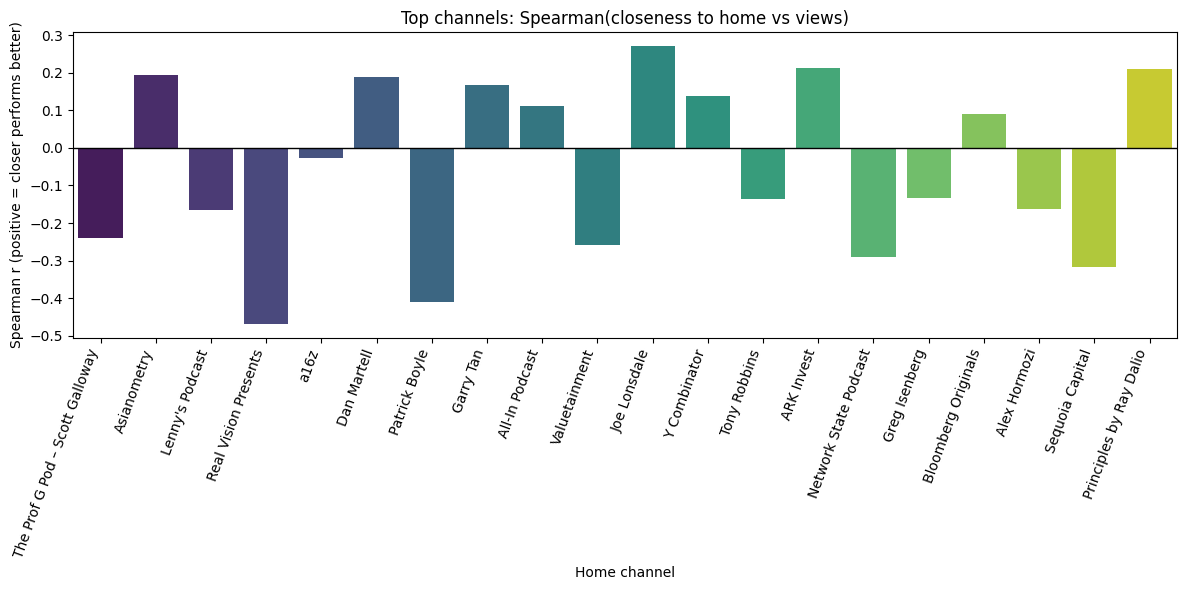

/tmp/ipykernel_24782/405738026.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_plot, x='profile_cluster', y='spearman_gradient_vs_views', palette='coolwarm')


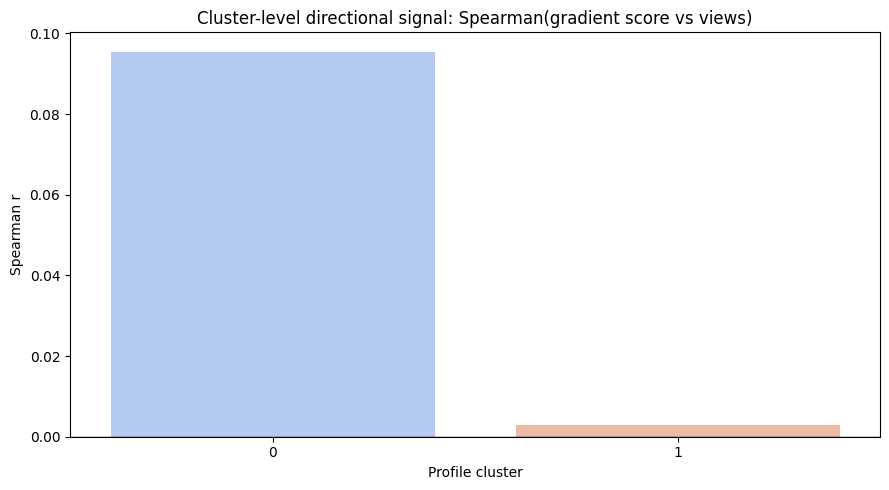

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = channel_metrics_df.dropna(subset=['spearman_closeness_vs_views']).copy()
plot_df = plot_df.sort_values('n_videos', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='home_channel_title', y='spearman_closeness_vs_views', palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=70, ha='right')
plt.title('Top channels: Spearman(closeness to home vs views)')
plt.xlabel('Home channel')
plt.ylabel('Spearman r (positive = closer performs better)')
plt.tight_layout()
plt.show()

cluster_plot = cluster_signal_df.copy()
plt.figure(figsize=(9, 5))
sns.barplot(data=cluster_plot, x='profile_cluster', y='spearman_gradient_vs_views', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.title('Cluster-level directional signal: Spearman(gradient score vs views)')
plt.xlabel('Profile cluster')
plt.ylabel('Spearman r')
plt.tight_layout()
plt.show()


## Persist artifacts for downstream interpretation
This cell writes all key tables (video-level scores, channel/global summaries, and cluster diagnostics) plus a JSON summary to Drive for reproducible downstream reporting.


In [17]:
import json

artifact_root = Path('/content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest')
artifact_root.mkdir(parents=True, exist_ok=True)

cross_distance_csv_path = artifact_root / 'video_cross_channel_distances.csv'
scored_csv_path = artifact_root / 'video_gradient_scores.csv'
channel_metrics_csv_path = artifact_root / 'channel_metrics_closeness_gradient.csv'
cluster_selection_csv_path = artifact_root / 'cluster_model_selection.csv'
cluster_signal_csv_path = artifact_root / 'cluster_signal_summary.csv'
cluster_top_mix_csv_path = artifact_root / 'top_signal_cluster_channel_mix.csv'
summary_json_path = artifact_root / 'summary.json'

cross_distance_df.to_csv(cross_distance_csv_path, index=False)
scored_df.to_csv(scored_csv_path, index=False)
channel_metrics_df.to_csv(channel_metrics_csv_path, index=False)
selection_df.to_csv(cluster_selection_csv_path, index=False)
cluster_signal_df.to_csv(cluster_signal_csv_path, index=False)
cluster_channel_mix.to_csv(cluster_top_mix_csv_path, index=False)

summary = {
    'artifact_root': str(artifact_root),
    'cross_distance_csv': str(cross_distance_csv_path),
    'scored_csv': str(scored_csv_path),
    'channel_metrics_csv': str(channel_metrics_csv_path),
    'cluster_selection_csv': str(cluster_selection_csv_path),
    'cluster_signal_csv': str(cluster_signal_csv_path),
    'cluster_top_mix_csv': str(cluster_top_mix_csv_path),
    'top_signal_cluster': int(top_cluster_id),
    'aggregate_stats': aggregate_stats,
}
summary_json_path.write_text(json.dumps(summary, indent=2))

print('Saved artifacts:')
for k, v in summary.items():
    if k != 'aggregate_stats':
        print(f' - {k}: {v}')
print(' - aggregate_stats included in summary.json')


Saved artifacts:
 - artifact_root: /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest
 - cross_distance_csv: /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/video_cross_channel_distances.csv
 - scored_csv: /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/video_gradient_scores.csv
 - channel_metrics_csv: /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/channel_metrics_closeness_gradient.csv
 - cluster_selection_csv: /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/cluster_model_selection.csv
 - cluster_signal_csv: /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/cluster_signal_summary.csv
 - cluster_top_mix_csv: /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/top_signal_cluster_channel_mix.c

## How to read the updated outputs
- `closeness_to_home` and its correlations use the **inverted framing**: larger means semantically closer, so positive correlation means “closer performs better.”
- `gradient_weighted_score` captures whether directional movement follows subscription adjacency (with-gradient) or fights it (against-gradient).
- Global stats summarize portfolio-level signal, while cluster diagnostics isolate where signal is concentrated.
- Start interpretation with `summary.json`, then drill into `channel_metrics_closeness_gradient.csv` and `cluster_signal_summary.csv`.
